# Задачи к Лекции 2

__Исходные данные__ 

Дан файл **"mlbootcamp5_train.csv"**. В нем содержатся данные об опросе 70000 пациентов с целью определения наличия заболеваний сердечно-сосудистой системы (ССЗ). Данные в файле промаркированы и если у человека имееются ССЗ, то значение **cardio** будет равно 1, в противном случае - 0. Описание и значения полей представлены во второй лекции.

__Загрузка файла__

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("mlbootcamp5_train.csv", 
                 sep=";", 
                 index_col="id")
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
id,,,,,,,,,,,,
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Немного исследования данных

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.9 MB


Посмотрим баланс классов

In [3]:
df['cardio'].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

В принципе, очень даже сбалансировано

Изучим данные на выбросы

<Axes: >

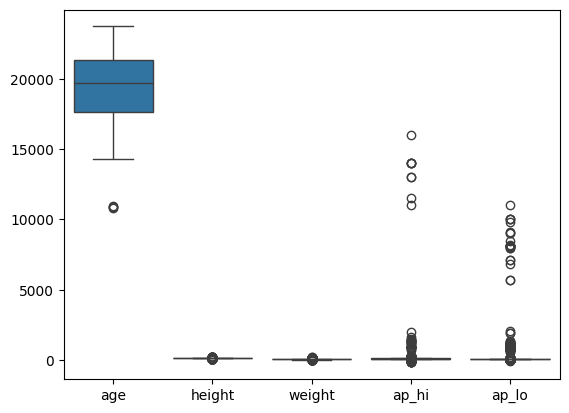

In [4]:
sns.boxplot(df[['age', 'height', 'weight', 'ap_hi', 'ap_lo']])

<Axes: ylabel='weight'>

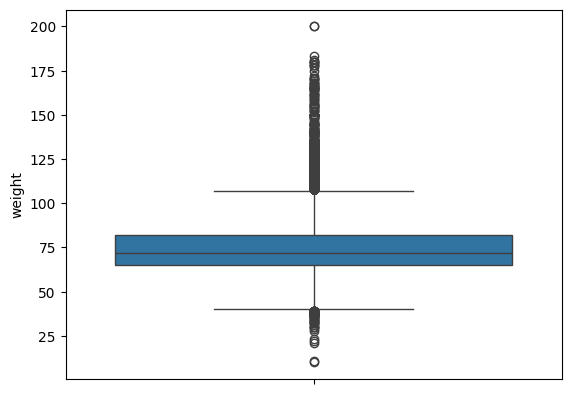

In [5]:
sns.boxplot(df['weight'])

In [6]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
def get_rid_of_outliers(feature: pd.Series) -> None:
    q1 = np.percentile(feature, 25)
    q3 = np.percentile(feature, 75)
    iqr = q3 - q1
    restrict_q3 = q3 + 1.5 * iqr
    restrict_q1 = q1 - 1.5 * iqr
    mediana = feature.median()

    for i in feature.index:
        if feature[i] < restrict_q1 or feature[i] > restrict_q3:
            feature[i] = mediana        
    

In [8]:
# заменяем выбросы на медианные
for col in ['age', 'height', 'weight', 'ap_hi', 'ap_lo']:
    get_rid_of_outliers(df[col])

<Axes: >

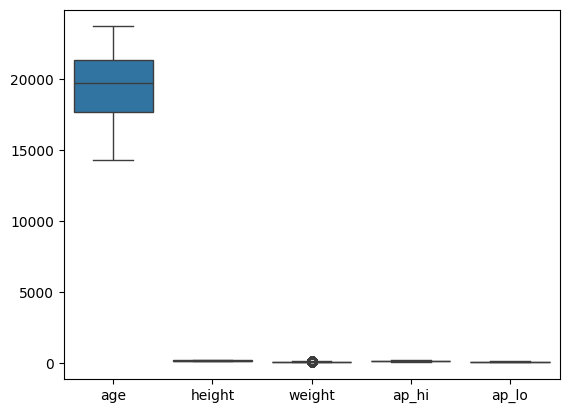

In [9]:
sns.boxplot(df[['age', 'height', 'weight', 'ap_hi', 'ap_lo']])

## Задачи

**1. Построить наивный байесовский классификатор для количественных полей age, height, weight, ap_hi, ap_lo. Исправить данные, если это необходимо. Привести матрицу неточностей и сравнить со значением полученным в ходе лекции. Попытаться объяснить разницу.**

In [97]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, CategoricalNB, BernoulliNB

In [123]:
class bayes_quant:
    
    def __init__(self, params_pos={}, params_neg={}, proba_p=0, proba_n=0) -> None:
        self.params_pos = params_pos
        self.params_neg = params_neg
        self.proba_p = proba_p  
        self.proba_n = proba_n
        
    
    def train(self, x: pd.DataFrame, y: pd.Series) -> None:
        '''Эта функция предназначена для обучения Байесовского наивного классификатора для задачи бинарной классификации 
        x - набор признаков, тип данных - pd.DataFrame; 
        y - целевая переменная, тип данных - pd.Series'''
        features = list(x.columns)
        self.proba_p = y[y == 0].shape[0] / y.shape[0]
        self.proba_n = y[y == 1].shape[0] / y.shape[0]
  
            # рассчитываем значения для класса 0
        for col in features:
            self.params_pos.setdefault('std ' + col, x[y == 0][col].agg(np.std))
            self.params_pos.setdefault('mu ' + col, x[y == 0][col].agg(np.mean)) # матожидание
            
                # рассчитываем значения для класса 1
            self.params_neg.setdefault('std ' + col, x[y == 1][col].agg(np.std)) 
            self.params_neg.setdefault('mu ' + col, x[y == 1][col].agg(np.mean))
        
    
    def predict(self, x: pd.DataFrame) -> list[int]:
        '''Эта функция предназначена для предсказания класса
        x - набор признаков, тип данных - pd.DataFrame'''
        from math import log, sqrt, e, pi
        features = list(x.columns)
        indexes = list(x.index)
        feature_lst_pos = {}
        feature_lst_neg = {}
        list_of_classes = []

        for feat in features:
            feature_lst_pos.setdefault(feat, {})
            feature_lst_neg.setdefault(feat, {})
        
        for row in indexes:
            proba_sum_pos = 0
            proba_sum_neg = 0
            
            for col in features:
                variable = x.loc[row, col] # значение признака
                
                # плотности вероятностей для классов
                ro_pos = (1 / (self.params_pos['std ' + col] * sqrt(2.0 * pi))) * (e ** (-(((variable - self.params_pos['mu ' + col]) ** 2) / (2 * self.params_pos['std ' + col] ** 2)))) 
                ro_neg = (1 / (self.params_neg['std ' + col] * sqrt(2.0 * pi))) * (e ** (-(((variable - self.params_neg['mu ' + col]) ** 2) / (2 * self.params_neg['std ' + col] ** 2)))) 


                # суммы для формулы вероятности
                proba_sum_pos += log(ro_pos + 1e-15) # + 1е-15, чтобы избежать ValueError
                proba_sum_neg += log(ro_neg + 1e-15)

            proba_neg = log(self.proba_p) + proba_sum_neg
            proba_pos = log(self.proba_n) + proba_sum_pos
         
            
            if proba_neg > proba_pos: # определяем класс + сохраняем вероятность
                list_of_classes.append(1)
            elif proba_neg < proba_pos:
                list_of_classes.append(0)
            elif proba_neg == proba_pos: # лучше определить, как больного в случае равенства вероятностей
                list_of_classes.append(1)

        return list_of_classes
    
        
    
    def save_toPkl(self, filename_pos: str, filename_neg) -> None: # сохраняем данные модели в pkl-формат
        with open(filename, 'wb') as f:
            pickle.dump(self.params_pos, filename_pos)
            pickle.dump(self.params_neg, filename_neg)
        
    

In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['age', 'height', 'weight', 'ap_hi', 'ap_lo']], df['cardio'], test_size=0.2, stratify=df['cardio'])

In [125]:
bayes = bayes_quant()

In [126]:
bayes.train(X_train, y_train)

In [127]:
pred = bayes.predict(X_test)

In [128]:
# Матрица неточнестей
cnf_matrix = confusion_matrix(list(y_test), pred)
print(cnf_matrix)
print('Accuracy:', accuracy_score(y_test, pred))
print('F1-score:', f1_score(y_test, pred))
print('Recall:', recall_score(y_test, pred))

[[5755 1249]
 [2797 4199]]
Accuracy: 0.711
F1-score: 0.674863387978142
Recall: 0.6002001143510578


Для сравнения посмотрим результаты классификатора из sklearn

In [129]:
div_bayes = GaussianNB()

In [130]:
div_bayes.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [131]:
pred = div_bayes.predict(X_test)

In [132]:
# Матрица неточностей
cnf_matrix = confusion_matrix(y_test, pred)
print(cnf_matrix)
print('Accuracy:', accuracy_score(y_test, pred))
print('F1-score:', f1_score(y_test, pred))
print('Recall:', recall_score(y_test, pred))

[[5755 1249]
 [2798 4198]]
Accuracy: 0.7109285714285715
F1-score: 0.6747568914248976
Recall: 0.6000571755288736


**Комментарии:** Метрики отличаются от тех, что были на лекции по возможным двум причинам: 1) другой способ работы с outliers (замена на медианные значения); 2) отсутсвие разбиения в лекции выборки на test и train

**2. Написать свой наивный байесовский классификатор для категориальных полей cholesterol, gluc. Привести матрицу неточностей и сравнить со значениями из задачи 1 (нельзя использовать готовое решение из sklearn) (не обязательно)**

In [133]:
class bayes_categorical:
    
    def __init__(self, params_pos={}, params_neg={}, alpha: float=0.1, proba_p=0, proba_n=0) -> None:
        self.params_pos = params_pos
        self.params_neg = params_neg
        self.alpha = alpha # для сглаживания Лапласа
        self.proba_p = proba_p
        self.proba_n = proba_n
               
    
    def train(self, x: pd.DataFrame, y: pd.Series) -> None:
        '''Эта функция предназначена для обучения Байесовского наивного классификатора для задачи бинарной классификации 
        x - набор признаков, тип данных - pd.DataFrame; 
        y - целевая переменная, тип данных - pd.Series'''
        self.params_pos = {}
        self.params_neg = {}
        features = list(x.columns)
        indexes = list(x.index)
        self.proba_p = y[y == 0].shape[0] / y.shape[0]
        self.proba_n = y[y == 1].shape[0] / y.shape[0]

        
        for feature in features:
            self.params_pos.setdefault(feature, {})
            self.params_neg.setdefault(feature, {})
        # создаем словарь со всеми вероятностями
            value_list = x[feature].unique()
            for value in value_list:
                
                p_pos = (x[(x[feature] == value) & (y == 0)].shape[0] + self.alpha) / (x[y == 0].shape[0] + self.alpha * len(value_list)) 
                p_neg = (x[(x[feature] == value) & (y == 1)].shape[0] + self.alpha) / (x[y == 1].shape[0] + self.alpha * len(value_list)) 

                self.params_pos[feature].setdefault(value, p_pos)
                self.params_neg[feature].setdefault(value, p_neg)
               
    
    def predict(self, x: pd.DataFrame) -> list[int]:
        '''Эта функция предназначена для предсказания класса
        x - набор признаков, тип данных - pd.DataFrame'''
        from math import log
        features = list(x.columns)
        indexes = list(x.index)
        p_basic = 0.5 # вероятность того, что человек либо болен, либо не болен
        list_of_classes = []


        for row in indexes:
            list_of_pos = []
            list_of_neg = []
            for col in features:
                value = x[col][row]
                
                list_of_pos.append(self.params_pos[col][value])
                list_of_neg.append(self.params_neg[col][value])

            proba_neg = log(self.proba_n) + sum(log(p) for p in list_of_neg)
            proba_pos = log(self.proba_p) + sum(log(p) for p in list_of_pos)
         
            
            if proba_neg > proba_pos: # определяем класс
                list_of_classes.append(1)
            elif proba_neg < proba_pos:
                list_of_classes.append(0)
            elif proba_neg == proba_pos:
                list_of_classes.append(1)
    
        return list_of_classes        
    
    def save_toPkl(self, filename_pos: str, filename_neg) -> None: # сохраняем данные модели в pkl-формат
        with open(filename, 'wb') as f:
            pickle.dump(self.params_pos, filename_pos)
            pickle.dump(self.params_neg, filename_neg)
        
    

In [134]:
bayes_cat = bayes_categorical()

In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['cholesterol', 'gluc']], df['cardio'], test_size=0.2, stratify=df['cardio'])

In [136]:
bayes_cat.train(X_train, y_train)

In [137]:
pred = bayes_cat.predict(X_test)

In [138]:
# Матрица неточнестей
cnf_matrix = confusion_matrix(list(y_test), pred)
print(cnf_matrix)
print('Accuracy:', accuracy_score(y_test, pred))
print('F1-score:', f1_score(y_test, pred))
print('Recall:', recall_score(y_test, pred))

[[5500 1504]
 [4203 2793]]
Accuracy: 0.5923571428571428
F1-score: 0.49464269901709024
Recall: 0.3992281303602058


Сравним с sklearn

In [139]:
cat = CategoricalNB()

In [140]:
cat.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


In [141]:
pred = cat.predict(X_test)

In [142]:
# Матрица неточностей
cnf_matrix = confusion_matrix(y_test, pred)
print(cnf_matrix)
print('Accuracy:', accuracy_score(y_test, pred))
print('F1-score:', f1_score(y_test, pred))
print('Recall:', recall_score(y_test, pred))

[[5500 1504]
 [4203 2793]]
Accuracy: 0.5923571428571428
F1-score: 0.49464269901709024
Recall: 0.3992281303602058


Результаты те же

**Комментарии:** Значения значительно ниже, чем в первом задании. Возможно, это специфика типа данных.

**3. Построить наивный байесовский классификатор для бинарных полей gender, smoke, alco, active. Привести матрицу неточностей и сравнить с предыдущими значениями.**

In [147]:
class bayes_binary:
    
    def __init__(self, params_pos={}, params_neg={}, proba_p=0, proba_n=0) -> None:
        self.params_pos = params_pos
        self.params_neg = params_neg
        self.proba_p = proba_p  
        self.proba_n = proba_n
            
    
    def train(self, x: pd.DataFrame, y: pd.Series) -> None:
        '''Эта функция предназначена для обучения Байесовского наивного классификатора для задачи бинарной классификации 
        x - набор признаков, тип данных - pd.DataFrame; 
        y - целевая переменная, тип данных - pd.Series'''
        features = list(x.columns)
        indexes = list(x.index)
        self.params_pos = {}
        self.params_neg = {}
        self.proba_p = y[y == 0].shape[0] / y.shape[0]
        self.proba_n = y[y == 1].shape[0] / y.shape[0]

        for feature in features:
            self.params_pos.setdefault(feature, {})
            self.params_neg.setdefault(feature, {})
        # создаем словарь со всеми вероятностями

            for value in [0, 1]:
                pos = (x[(x[feature] == value) & (y == 0)].shape[0] + 1) / (y[y == 0].shape[0] + 2)
                neg = (x[(x[feature] == value) & (y == 1)].shape[0] + 1) / (y[y == 1].shape[0] + 2)
             
                self.params_pos[feature].setdefault(value, pos)
                self.params_neg[feature].setdefault(value, neg)
        
    
    def predict(self, x: pd.DataFrame) -> list[int]:
        '''Эта функция предназначена для предсказания класса
        x - набор признаков, тип данных - pd.DataFrame'''
        from math import log
        features = list(x.columns)
        indexes = list(x.index)
        list_of_classes = []

        for row in indexes:
            list_of_pos = []
            list_of_neg = []
            for col in features:
                value = x[col][row]
                
                list_of_pos.append(self.params_pos[col][value])
                list_of_neg.append(self.params_neg[col][value])


                proba_neg = log(self.proba_n) + sum(log(p) for p in list_of_neg)
                proba_pos = log(self.proba_p) + sum(log(p) for p in list_of_pos)
         
            
            if proba_neg > proba_pos: # определяем класс 
                list_of_classes.append(1)
            elif proba_neg < proba_pos:
                list_of_classes.append(0)
            elif proba_neg == proba_pos:
                list_of_classes.append(1)

        return list_of_classes
    
        
    
    def save_toPkl(filename_pos: str, filename_neg) -> None: # сохраняем данные модели в pkl-формат
        with open(filename, 'wb') as f:
            pickle.dump(self.params_pos, filename_pos)
            pickle.dump(self.params_neg, filename_neg)
        
    

In [144]:
df['gender'].unique()

array([1, 0], dtype=int64)

In [64]:
#df['gender'] = df['gender'] - 1 # чтобы были только 0 и 1

In [145]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['gender', 'smoke', 'alco', 'active']], df['cardio'], test_size=0.2, stratify=df['cardio'])

In [148]:
bayes_bin = bayes_binary()

In [149]:
bayes_bin.train(X_train, y_train)

In [151]:
pred = bayes_bin.predict(X_test)

In [152]:
# Матрица неточнестей
cnf_matrix = confusion_matrix(list(y_test), pred)
print(cnf_matrix)
print('Accuracy:', accuracy_score(y_test, pred))
print('F1-score:', f1_score(y_test, pred))
print('Recall:', recall_score(y_test, pred))

[[5720 1284]
 [5523 1473]]
Accuracy: 0.5137857142857143
F1-score: 0.302060904337127
Recall: 0.21054888507718697


In [153]:
binNB = BernoulliNB()

In [154]:
binNB.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [155]:
pred = binNB.predict(X_test)

In [156]:
# Матрица неточностей
cnf_matrix = confusion_matrix(y_test, pred)
print(cnf_matrix)
print('Accuracy:', accuracy_score(y_test, pred))
print('F1-score:', f1_score(y_test, pred))
print('Recall:', recall_score(y_test, pred))

[[5720 1284]
 [5523 1473]]
Accuracy: 0.5137857142857143
F1-score: 0.302060904337127
Recall: 0.21054888507718697


**Комментарии:** Значения ниже, чем в предыдущем задании. Возможно, что также роль играет специфика данных и их обработка

**4. К этому моменту у вас есть три независимых классификатора: по количественным полям, категориальным и бинарным. Придумать, как их объединить в один единый классификатор, который учитывает все эти поля. Привести матрицу неточностей для него и сравнить с предыдущими значениями. Попытаться объяснить разницу.**

In [180]:
class Naive_Bayes:
    '''Класс для классификации категориальных, бинарных и количественных данных 
    при помощи наивного байесовского классификатора. В качестве переменных 
    предоставьте три классификатора: категориальный, бинарный и количественный'''
    
    def __init__(self, bayes_category, bayes_bin, bayes_quantitative) -> None:
        self.bayes_category = bayes_category
        self.bayes_bin = bayes_bin
        self.bayes_quantitative = bayes_quantitative
        

    def train(self, x_cat: pd.DataFrame, y_cat: pd.Series,
             x_bin: pd.DataFrame, y_bin: pd.Series,
             x_quant: pd.DataFrame, y_quant: pd.Series) -> None:
        '''Функция для обучения моделей. 
        x_cat: категориальные данные, пространство признаков
        y_cat: категориальные данные, target variable
        x_bin: бинарные данные, пространство признаков
        y_bin: бинарные данные, target variable
        x_quant: количественные данные, пространство признаков
        y_quant: количественные данные, target variable'''
        
        self.bayes_category.train(x_cat, y_cat)
        self.bayes_bin.train(x_bin, y_bin)
        self.bayes_quantitative.train(x_quant, y_quant)
        

    def predict(self, x_cat: pd.DataFrame, 
                x_bin: pd.DataFrame, x_quant: pd.DataFrame) -> list[int]:
        '''Функция для предсказывания класса
        x_cat: категориальные данные
        x_bin: бинарные данные
        x_quant: количественные данные
        '''
        pred_cat = self.bayes_category.predict(x_cat)
        pred_bin = self.bayes_bin.predict(x_bin)
        pred_quant = self.bayes_quantitative.predict(x_quant)

        list_of_classes = []

        for s in zip(pred_cat, pred_bin, pred_quant):
            if s.count(0) > s.count(1):
                list_of_classes.append(0)
            else:
                list_of_classes.append(1)

        return list_of_classes
        

In [181]:
nb = Naive_Bayes(bayes_categorical(), bayes_binary(), bayes_quant())

In [182]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['age', 'height', 'weight', 'ap_hi', 'ap_lo'
        , 'cholesterol', 'gluc', 'gender', 'smoke', 'alco', 
        'active']], df['cardio'], test_size=0.2, stratify=df['cardio'])

In [183]:
a = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
b = ['cholesterol', 'gluc']
c = ['gender', 'smoke', 'alco', 'active']

In [190]:
X_train_b, X_test_b = X_train[c], X_test[c]
X_train_c, X_test_c = X_train[b], X_test[b]
X_train_q, X_test_q = X_train[a], X_test[a]

In [191]:
nb.train(X_train_c, y_train, X_train_b, y_train, X_train_q, y_train)

In [192]:
pred = nb.predict(X_test_c, X_test_b, X_test_q)

In [193]:
# Матрица неточностей
cnf_matrix = confusion_matrix(y_test, pred)
print(cnf_matrix)
print('Accuracy:', accuracy_score(y_test, pred))
print('F1-score:', f1_score(y_test, pred))
print('Recall:', recall_score(y_test, pred))

[[6189  815]
 [4478 2518]]
Accuracy: 0.6219285714285714
F1-score: 0.4875592990608965
Recall: 0.3599199542595769


**Комментарии:** Метрики здесь по сути представляют усредненные значения метрик, вычисленных ранее.

**5. (Не обязательно) Теперь мы умеем делать классификацию в рамках наивного предположения об независимости всех признаков. Сейчас же нужно попробовать учесть взаимосвязь между признаками через условные вероятности. Построить классификатор с учетом такой связи. Сравнить результат с ранее полученными значениями.**

In [3]:
# A lot of code here

**Комментарии:** Ваши комментарии здесь.